In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sam_one = SAM()
sam_one.load_data('../../Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')

sam_two = SAM()
sam_two.load_data('../../Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_07282026.h5ad')

sam_three = SAM()
sam_three.load_data('../../Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_08182025_MNPO.h5ad')

sam_four = SAM()
sam_four.load_data('../../Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_08182025_MNPO.h5ad')

sam_five = SAM()
sam_five.load_data('../../Subclustering/MNPO/SAM_RI_joined_cleaned_08032026_sssubclass_MNPO.h5ad')

In [5]:
sams = {'mg':sam_one,'mo':sam_two,'cj':sam_three,'ac':sam_four,'ri':sam_five}

sm = SAMAP(
    sams,
    f_maps = '../../BLASTMAPPING/maps/active_maps/hypo_proj/',
)

Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
20843 `mg` gene symbols match between the datasets and the BLAST graph.
18042 `mo` gene symbols match between the datasets and the BLAST graph.
15940 `cj` gene symbols match between the datasets and the BLAST graph.
20346 `ac` gene symbols match between the datasets and the BLAST graph.
21128 `ri` gene symbols match between the datasets and the BLAST graph.


In [6]:
sm.run(pairwise=True)

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 19.7726092338562
Correcting data with means. 22.317694902420044
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 0 
Average alignment score (A.S.):  0.40426095835714543 
Max A.S. improvement: 0.8317100515971534 
Min A.S. improvement: 0.0
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 15.583549499511719
Correcting data with means. 17.559743642807007
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 1 
Average alignment score (A.S.):  0.49405193383132584 
Max A.S. improvement: 0.34529456156065125 
Min A.S. improvement: -0.1275259214151193
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 15.088041305541992
Correcting data with means. 16.510220050811768
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
ITERATION: 2 
Average alignment score (A.S.):  0.5108111761926802 
Max A.S. improvement: 0.1589002250888778 
Min A.S. improvement: -0.11595439708804106
Alignment score --- 0.5108111761926802
Running UMAP on the stitched manifolds.
Elapsed time: 5.1958248853683475 minutes.


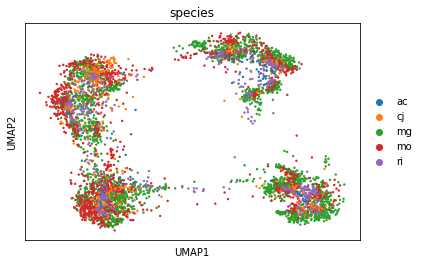

In [7]:
sc.pl.umap(sm.samap.adata, color = 'species')

In [8]:
save_samap(sm, '../../Subclustering/MNPO/sm_hypoorgs_MNPO_08042026.pkl')